In [1]:
import pandas as pd
import os
from utils.ml_utils import PreprocessingUtils, GBEmissionsPredictionPipeline, RFEmissionsPredictionPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
PREDICTORS_DIR_PATH = os.path.join(DATA_DIR_PATH, "predictors")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_run_2025-01-14T17;04;06.975301_output_database")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v2.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,total_positive_emissions,total_negative_emissions
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,590.733125,-329.489684
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.536533,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,482.293940,-232.721324
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.533412,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,308.455155,-334.229504
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.264120,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,543.963408,-314.565592
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.430582,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,485.590028,-360.621588


In [5]:
# Set some parameters
use_pca = False

## EDA

In [6]:
edau = EDAUtils()

In [7]:
emission_cols = [col for col in training_df.columns if "emissions" in col]
emission_cols

['total_positive_emissions', 'total_negative_emissions']

In [8]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
# lhs_group_cols

In [9]:
training_df[emission_cols].describe()

,total_positive_emissions,total_negative_emissions
count,9.840000e+02,984.000000
mean,1.048853e+06,-327.407579
std,1.452470e+07,48.328630
min,3.050774e+02,-445.198593
25%,4.810368e+02,-362.746904
50%,5.430467e+02,-326.714245
75%,6.039665e+02,-292.208945
max,3.037558e+08,-214.047846


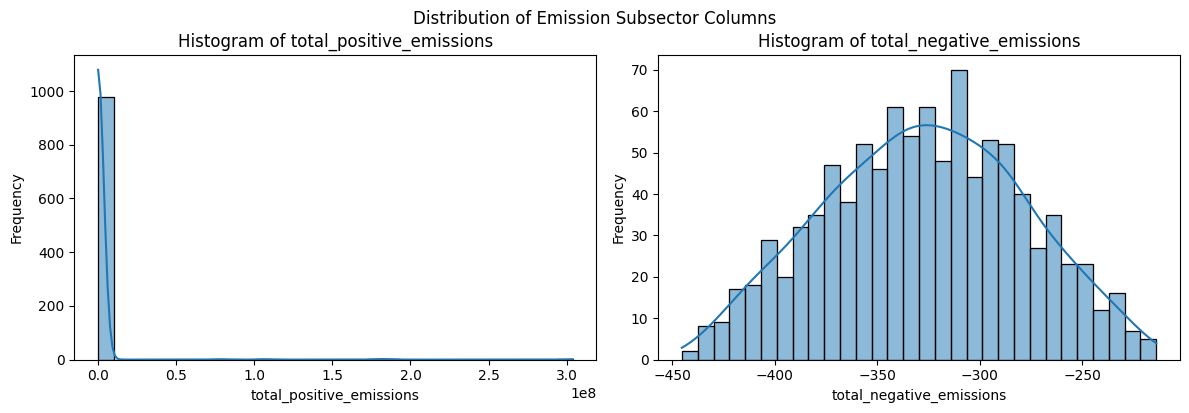

In [10]:
edau.plot_multiple_histograms(training_df, emission_cols, title="Distribution of Emission Subsector Columns")


In [11]:
edau.get_target_var_corr(training_df, "total_positive_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000



In [12]:
edau.get_target_var_corr(training_df, "total_negative_emissions")


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.6417



In [13]:
# Find constant / near-constant cols
const_cols = edau.find_constant_columns(training_df)
near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
print("Constant:", const_cols)
print("Near-constant:", near_const_cols)

Constant: []
Near-constant: []


In [14]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.6097560975609756}


## Data Cleaning

In [15]:
dcu = DataCleaningUtils()

In [16]:
training_df.shape

(984, 48)

In [17]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (978, 48)


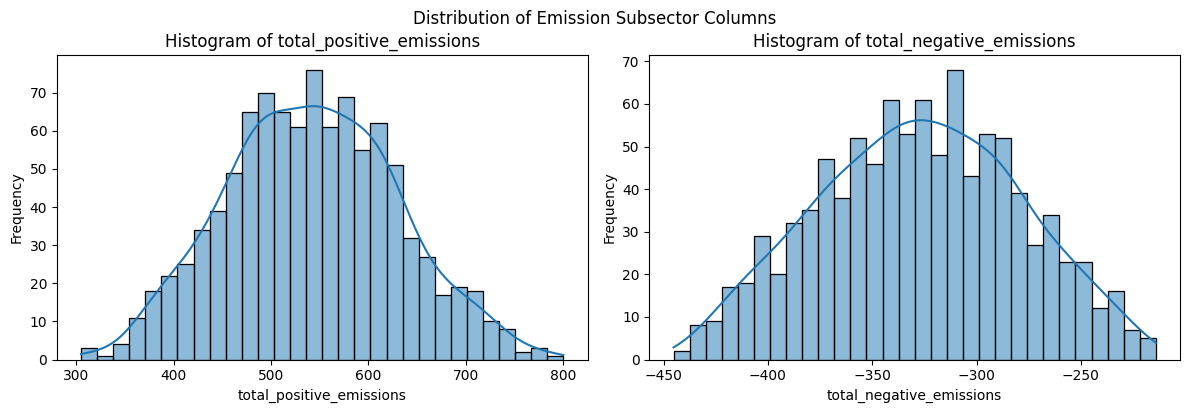

In [18]:
edau.plot_multiple_histograms(training_df_cleaned, emission_cols, title="Distribution of Emission Subsector Columns")

In [19]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [20]:
edau.get_target_var_corr(training_df_cleaned, "total_positive_emissions")
edau.get_target_var_corr(training_df_cleaned, "total_negative_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000
group_34_nemomod_en            : 0.6391
group_17_frac_trns_fuelmix     : 0.4504
group_26_frac_inen_energy      : 0.4400
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1537
total_negative_emissions       : 0.1427
group_47_scalar_scoe_heat_energy_demand : 0.1199
group_4_demscalar_ippu         : 0.1159
group_19_frac_trns_pkm_dem     : 0.1102
group_22_frac_waso             : 0.1028


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.6434
total_positive_emissions       : 0.1427



In [21]:
training_df_cleaned[emission_cols].describe()

,total_positive_emissions,total_negative_emissions
count,978.000000,978.000000
mean,542.051218,-327.579060
std,87.808697,48.394721
min,305.077380,-445.198593
25%,480.213918,-362.855166
50%,542.641431,-327.073961
75%,602.956046,-292.436642
max,800.176534,-214.047846


## Preprocessing

In [22]:
ppu = PreprocessingUtils()

## ML

In [25]:
for emission_type in emission_cols:
    epp = GBEmissionsPredictionPipeline(training_df_cleaned[lhs_group_cols + [emission_type]], target=emission_type, test_size=0.2, random_state=42)
    print(f"Running pipeline for emission_type: {emission_type}")
    epp.run(tune=True, log_transform=False, create_plots=False)
    print("=" * 50)

Running pipeline for emission_type: total_positive_emissions
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 11, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.5}
Baseline MAE: 74.7838
Baseline RMSE: 89.7130
Baseline R²: -0.0118
Predicted Mean: 543.9897
--------------------------------------------------
MAE:   28.1463
RMSE:  34.9437
R²:    0.8465
SMAPE: 5.33%
--------------------------------------------------

Cross-Validation Results:
test_MAE: Mean=27.9979, Std=1.3300
test_R2: Mean=0.8339, Std=0.0198
test_RMSE: Mean=35.3396, Std=1.2233
Running pipeline for emission_type: total_negative_emissions
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: 
All the 150 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/xgboost/sklearn.py", line 1222, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tony-ubuntu/anaconda3/e

Running pipeline for emission_type: total_positive_emissions
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
MAE: 29.010469276627617
RMSE: 36.71250614167806
R^2 Score: 0.8305680674296102


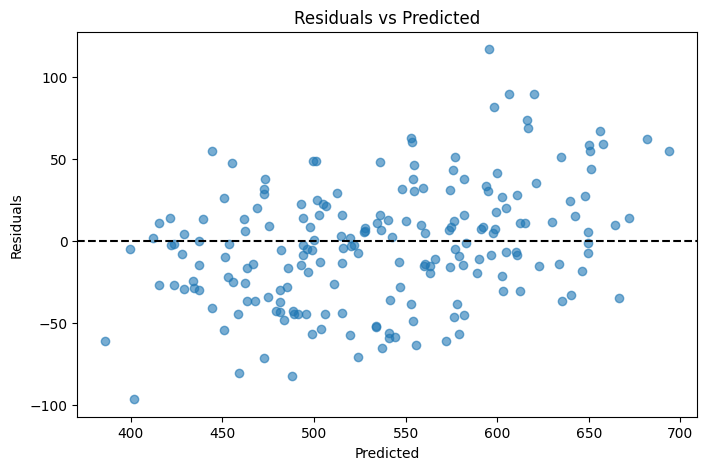

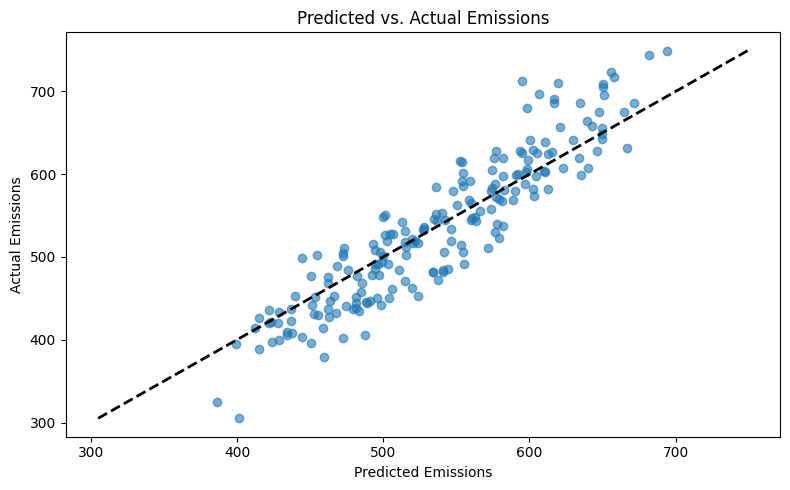

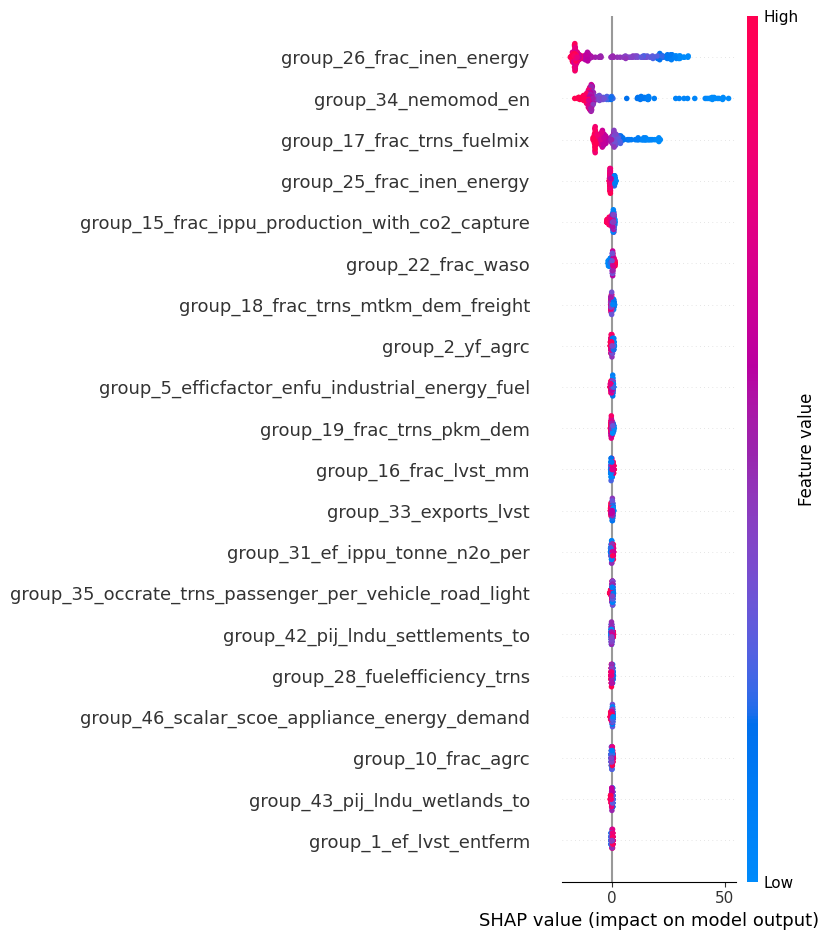


Cross-Validation Results:
test_MAE: Mean=-32.0974, Std=1.8202
test_R2: Mean=0.7821, Std=0.0259
test_RMSE: Mean=-40.4833, Std=1.5070


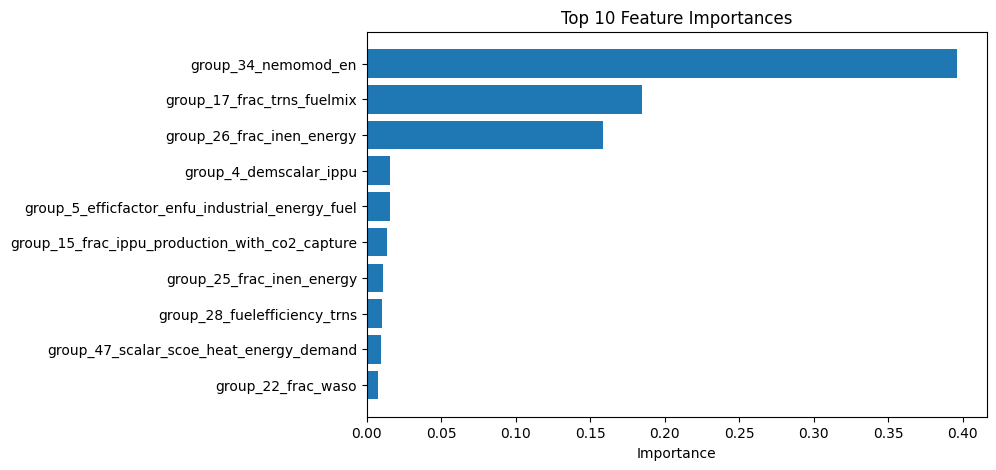

Running pipeline for emission_type: total_negative_emissions
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: 
All the 150 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py", line 360, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/home/tony-ubuntu/anaconda3

In [26]:
for emission_type in emission_cols:
    rf_pipeline = RFEmissionsPredictionPipeline(training_df_cleaned[lhs_group_cols + [emission_type]], target=emission_type, test_size=0.2, random_state=42)
    print(f"Running pipeline for emission_type: {emission_type}")
    rf_pipeline.run(tune=True, log_transform=False)
    print("=" * 50)